# 4. Dependence changes: is it real, or just noise?

**What you will do**

1. Track dependence over time: average dependence, tail dependence, which pairs changed.
2. See how much the fitted *vine structure* itself jumps around from day to day.
3. Measure structural change in a way that separates real shifts from estimation noise, using a **permutation test**.
4. Learn from simulated data where the true answer is known, including what the method *cannot* detect.

**The central point.** A rolling model always moves a little: every window contains slightly different days, so every
estimate has sampling noise. The project therefore asks one question again and again: *is the dependence in the latest
window different from the window before it by more than noise would explain?*

**Before you start:** notebook 3 (it makes a small demo run), or better the full run (`python scripts/run_rolling.py`).
Everything here works with either; with the full run you see 20 years, with the demo run about a year and a half.

In [1]:
import os, warnings
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # notebooks run from the notebooks/ folder; the project root is one level up
    ROOT = ROOT.parent
os.chdir(ROOT)                    # all paths below are relative to the project folder
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("working folder:", Path.cwd().name)

working folder: Quant_copula


In [2]:
from vine_risk.config import load_config
from vine_risk.pipeline import find_run, load_prices_and_returns
from vine_risk.rolling import load_results
from vine_risk.change_detection import default_lag

cfg = load_config("configs/default.yaml")
prices, returns = load_prices_and_returns(cfg)

RUN = find_run()                                   # data/results/w250 if it exists, otherwise data/results/demo
results = load_results(RUN / "checkpoint.jsonl")
window = results[0].n_obs
pos = returns.index.get_indexer(pd.DatetimeIndex([r.timestamp for r in results]))
freq = int(np.median(np.diff(pos)))                # days between fits (1 for the full run, 5 for the demo run)
lag = default_lag(window, freq)                    # number of fits that make one full window
print(f"run: {RUN} | {len(results)} fits from {results[0].timestamp} to {results[-1].timestamp}")
print(f"window {window} days, a fit every {freq} day(s); one window = {lag} fits")

run: data/results/w250 | 5222 fits from 2005-12-29 to 2026-10-02
window 250 days, a fit every 1 day(s); one window = 250 fits


## 4.1 Level 1: dependence over time

`dependence_metrics` has one row per fit. `d_t` is the average absolute Kendall tau ("market interconnectedness").
`mean_lower_tail_q` and `mean_upper_tail_q` are the vine's implied tail dependence, averaged over all pairs.

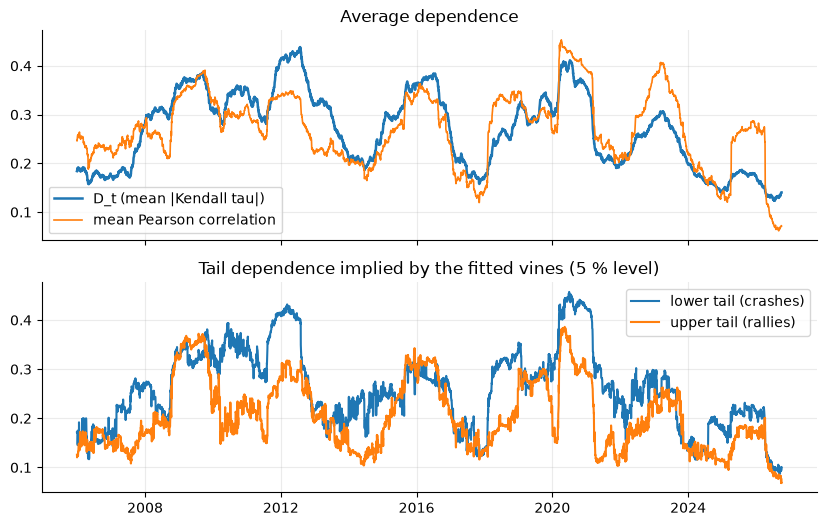

In [3]:
from vine_risk.dependence import dependence_metrics

m = dependence_metrics(results)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(m.index, m.d_t, lw=1.8, label="D_t (mean |Kendall tau|)")
axes[0].plot(m.index, m.mean_pearson, lw=1.2, label="mean Pearson correlation")
axes[0].legend(); axes[0].set_title("Average dependence")
axes[1].plot(m.index, m.mean_lower_tail_q, lw=1.5, label="lower tail (crashes)")
axes[1].plot(m.index, m.mean_upper_tail_q, lw=1.5, label="upper tail (rallies)")
axes[1].legend(); axes[1].set_title("Tail dependence implied by the fitted vines (5 % level)"); plt.show()

**Does the lower tail move differently from ordinary correlation?** One of the research questions. A first look: compare
how much each changed over one window.

correlation of the one-window changes:
             D_t  lower tail  upper tail
D_t         1.00        0.73        0.86
lower tail  0.73        1.00        0.62
upper tail  0.86        0.62        1.00


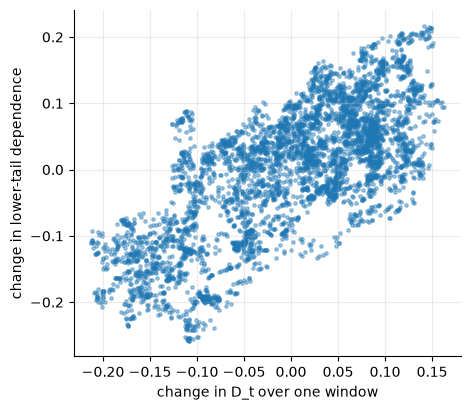

In [4]:
chg = pd.DataFrame({"D_t": m.d_t.diff(lag), "lower tail": m.mean_lower_tail_q.diff(lag), "upper tail": m.mean_upper_tail_q.diff(lag)}).dropna()
print("correlation of the one-window changes:")
print(chg.corr().round(2))
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(chg["D_t"], chg["lower tail"], s=6, alpha=.4); ax.set_xlabel("change in D_t over one window"); ax.set_ylabel("change in lower-tail dependence")
plt.show()

They move together (the correlation is high), but not one-for-one. Remember the limits: both come from the same fitted
vines, and these changes are heavily overlapping (neighbouring windows share most of their days), so this is a description,
not a test. The tail results of the permutation test below are more reliable.

## 4.2 Which pairs changed?

Change in Kendall tau of each pair over the last full window:

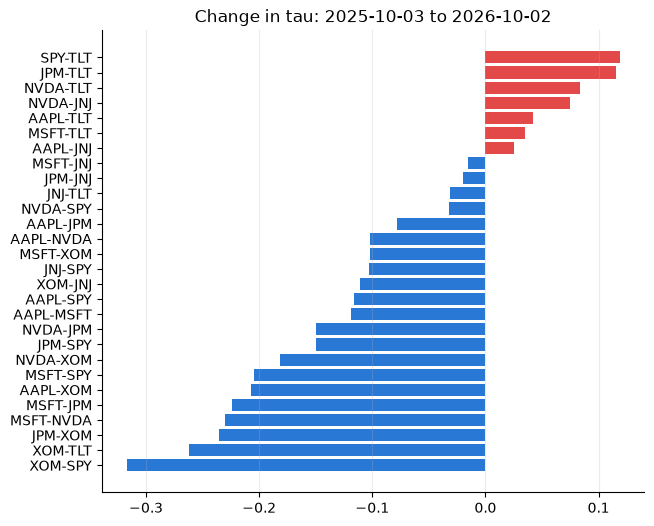

In [5]:
from vine_risk.dependence import pairwise_series

tau = pairwise_series(results, "tau")
delta = (tau.iloc[-1] - tau.iloc[-1 - lag]).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(delta.index, delta.values, color=np.where(delta.values > 0, "#e34948", "#2a78d6")); ax.grid(axis="y", alpha=0)
ax.set_title(f"Change in tau: {tau.index[-1 - lag].date()} to {tau.index[-1].date()}"); plt.show()

## 4.3 Level 2: how stable is the vine structure?

The PDF warns against reading every change in a fitted model as a change in the world. Compare each fit with the previous one:
how many tree-1 edges were replaced, how many pair-copulas switched family?

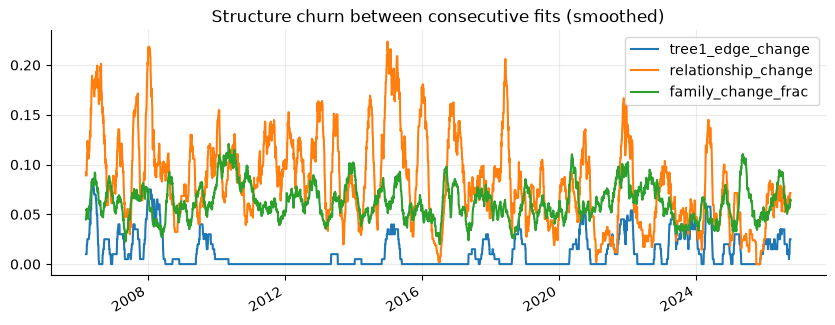

average share of pair-copulas present in both fits that switched family: 0.062


In [6]:
from vine_risk.dependence import structure_changes

sc = structure_changes(results)
roll = sc[["tree1_edge_change", "relationship_change", "family_change_frac"]].rolling(max(5, lag // 5)).mean()
fig, ax = plt.subplots(figsize=(10, 3.6))
roll.plot(ax=ax, lw=1.5); ax.set_title("Structure churn between consecutive fits (smoothed)"); plt.show()
print("average share of pair-copulas present in both fits that switched family:", round(sc.family_change_frac.mean(), 3))

The tree-1 skeleton is stable (the market index stays the hub); a noticeable share of pair-copulas swaps family from one fit
to the next. Different families can fit nearly equally well, so **family labels are weak evidence of change**; dependence
*levels* (tau, tail coefficients) are far more reliable. This is why the change scores below work on those, not on the labels.

## 4.4 Level 3: structural change scores

The simplest score is the distance between consecutive Kendall-tau matrices (the "S_t" of the project brief):
$S_t=\|T_t-T_{t-1}\|_F$ (Frobenius norm). But consecutive windows overlap in all but one day, so this measures almost nothing.
Compare it with the distance to the fit **one full window earlier**, which shares no days:

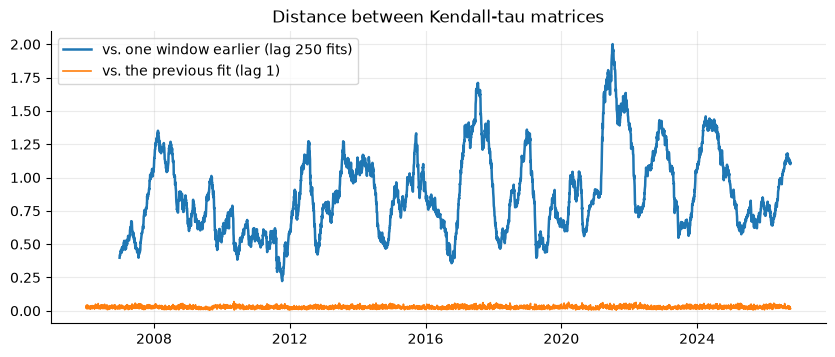

In [7]:
from vine_risk.change_detection import structural_change_scores

s_far = structural_change_scores(results, lag=lag, baseline=max(20, 500 // freq))
s_one = structural_change_scores(results, lag=1, baseline=max(20, 500 // freq))
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(s_far.index, s_far.s_tau, lw=1.8, label=f"vs. one window earlier (lag {lag} fits)")
ax.plot(s_one.index, s_one.s_tau, lw=1.2, label="vs. the previous fit (lag 1)")
ax.legend(); ax.set_title("Distance between Kendall-tau matrices"); plt.show()

The one-step distance is flat and tiny: it cannot see a change that takes months to build up. The one-year distance rises and
falls with real shifts in dependence (check it against the plot in 4.1). But how large is *large*? The raw distance has no
scale: it depends on the number of assets and on how noisy a window is. We need a null distribution.

## 4.5 A calibrated test: the permutation test

Take the two windows being compared (the last 250 days and the 250 before), pool their 500 days, and shuffle days between
the windows many times. Each shuffle gives a distance that arises by chance alone. If the *observed* distance is larger than
almost all shuffled ones, the dependence really differs. We shuffle blocks of 10 consecutive days to respect volatility
clustering. The test gives a p-value and an **effect size** (observed distance divided by the typical shuffled distance):
a p-value alone is not enough, because with a year of data even small differences are "significant".

In [8]:
from vine_risk.change_detection import change_scan, benjamini_hochberg

scan_file = RUN / "change_scan.parquet"
if scan_file.exists():
    scan = pd.read_parquet(scan_file); scan.index = pd.DatetimeIndex(scan.index)
    print("using the stored scan:", scan_file)
else:
    scan = change_scan(returns.iloc[-900:], window, step=5, n_perm=199, q=0.1, seed=cfg.risk.seed, block=10)
    print("computed a scan on the last 900 days")
scan["ratio_tau"] = scan.stat_tau / scan.null_mean_tau
scan["significant"] = scan.p_tau <= 0.01
scan["fdr"] = benjamini_hochberg(scan.p_tau, 0.01)
print(f"{len(scan)} scan dates | significant at 1 %: {scan.significant.mean():.0%} | after multiple-testing correction: {scan.fdr.mean():.0%}")
scan[["stat_tau", "null_mean_tau", "ratio_tau", "p_tau", "p_mean_lower"]].tail(5).round(3)

using the stored scan: data/results/w250/change_scan.parquet
995 scan dates | significant at 1 %: 41% | after multiple-testing correction: 30%


,stat_tau,null_mean_tau,ratio_tau,p_tau,p_mean_lower
timestamp,,,,,
2026-09-02,1.151,0.533,2.160,0.002,0.042
2026-09-10,1.136,0.542,2.094,0.004,0.024
2026-09-17,1.136,0.525,2.164,0.004,0.068
2026-09-24,1.119,0.544,2.059,0.002,0.022
2026-10-01,1.101,0.527,2.087,0.002,0.076


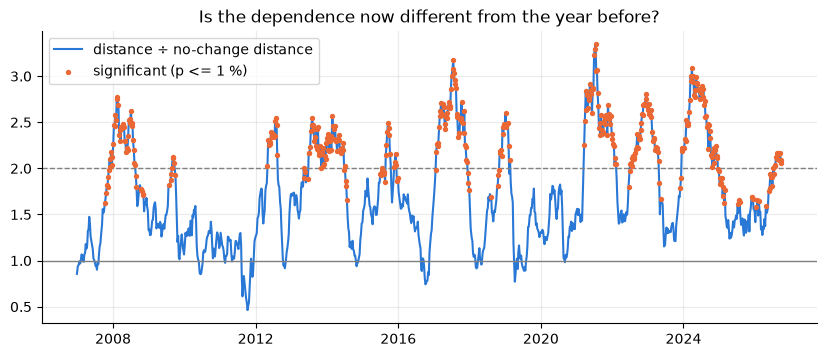

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(scan.index, scan.ratio_tau, lw=1.5, color="#2a78d6", label="distance ÷ no-change distance")
ax.scatter(scan.index[scan.significant], scan.ratio_tau[scan.significant], s=8, color="#eb6834", label="significant (p <= 1 %)", zorder=3)
ax.axhline(1, color="grey", lw=1); ax.axhline(2, color="grey", lw=1, ls="--")
ax.legend(); ax.set_title("Is the dependence now different from the year before?"); plt.show()

A ratio near 1 means "no more different than shuffling would produce". Two caveats from the validation study (section 4.7):
the test is calibrated (it flags about 1 % of dates when nothing changes), and it is *not* informative about **why** the dependence
differs. Also, we test many dates, so a few small p-values are expected by chance; the multiple-testing correction (`fdr`) accounts for that.

## 4.6 From test results to alerts

The monitor of notebook 6 turns this into alerts with two thresholds: an alert **starts** when the test is significant *and*
the effect is at least 2 times the no-change level, and **ends** when the effect falls below 1.5 (the gap prevents flickering).
Applied to the scan above:

In [10]:
from vine_risk.monitor import MonitorConfig, next_alert_state, WARMING_UP, ALERT

mc = MonitorConfig()                 # alpha 1 %, enter at 2.0, exit at 1.5
state, episodes, current = WARMING_UP, [], None
for date, r in scan.iterrows():
    state, new, _ = next_alert_state(state, r.p_tau, r.ratio_tau, mc)
    if new:
        current = {"start": date, "peak": r.ratio_tau}
    elif current is not None and state == ALERT:
        current["peak"] = max(current["peak"], r.ratio_tau)
    if current is not None and state != ALERT:
        current["end"] = date; episodes.append(current); current = None
if current is not None:
    current["end"] = "still on"; episodes.append(current)
eps = pd.DataFrame(episodes)
print(len(eps), "alert episode(s)"); eps.assign(peak=eps.peak.round(2))

11 alert episode(s)


,start,peak,end
0,2007-11-27,2.78,2008-12-30 00:00:00
1,2009-08-26,2.12,2009-10-15 00:00:00
2,2012-05-01,2.54,2012-09-21 00:00:00
3,2013-05-08,2.57,2014-07-31 00:00:00
4,2015-08-26,2.49,2016-05-06 00:00:00
5,2017-01-24,3.17,2018-01-12 00:00:00
6,2018-11-05,2.60,2019-03-26 00:00:00
7,2021-03-19,3.35,2022-03-09 00:00:00
8,2022-07-05,2.80,2023-06-09 00:00:00
9,2023-12-14,3.08,2025-03-06 00:00:00


## 4.7 Learning from simulated data (known truth)

Real data cannot tell us whether a detector is right. Simulated data can: we create returns whose dependence changes at a
**known date** and see whether the test notices. Three experiments (the full study is in `reports/validation/`):

* **B:** the correlation jumps from 0.3 to 0.7;
* **C1:** only the *tails* change (Gaussian to Student-t with 3 degrees of freedom, same Kendall tau);
* **C2:** a much stronger tail change (Student-t with 1 degree of freedom).

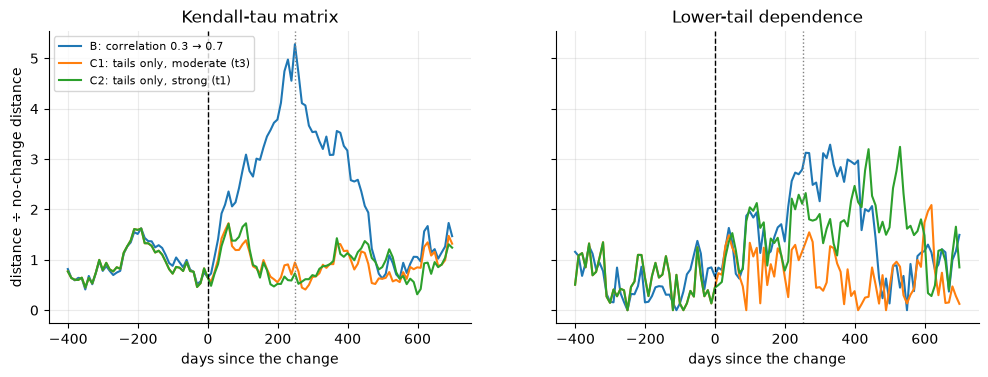

In [11]:
from vine_risk.synthetic import Regime, simulate_regimes

W, T0 = 250, 900
experiments = {
    "B: correlation 0.3 → 0.7": [Regime(T0, 0.3), Regime(700, 0.7)],
    "C1: tails only, moderate (t3)": [Regime(T0, 0.5), Regime(700, 0.5, df=3)],
    "C2: tails only, strong (t1)": [Regime(T0, 0.5), Regime(700, 0.5, df=1)],
}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for label, regimes in experiments.items():
    x = simulate_regimes(regimes, n_assets=4, seed=3)
    s = change_scan(x, W, step=10, n_perm=199, block=10, seed=3)
    axes[0].plot(np.arange(len(x))[2 * W - 1::10][:len(s)] - T0, s.stat_tau / s.null_mean_tau, label=label)
    axes[1].plot(np.arange(len(x))[2 * W - 1::10][:len(s)] - T0, s.stat_mean_lower / s.null_mean_mean_lower, label=label)
for ax, t in zip(axes, ["Kendall-tau matrix", "Lower-tail dependence"]):
    ax.axvline(0, color="k", ls="--", lw=1); ax.axvline(W, color="grey", ls=":", lw=1); ax.set_title(t); ax.set_xlabel("days since the change")
axes[0].set_ylabel("distance ÷ no-change distance"); axes[0].legend(fontsize=8); plt.show()

What to see: the correlation jump produces a clear hill that peaks about one window after the change (when the two compared
windows are split exactly at the change, dotted line). The tail-only changes are almost invisible; only the strong one lifts the
tail panel a little. The 20-replication study gives the numbers:

In [12]:
val = pd.read_csv("reports/validation/detection_scan.csv")
pick = val[val.statistic.isin(["tau", "mean_lower"])].copy()
pick["false_alarm"] = (100 * pick.false_alarm).round(0); pick["power"] = (100 * pick.power).round(0)
pick.pivot(index="experiment", columns="statistic", values=["false_alarm", "power"]).rename(columns=lambda c: c + " (%)", level=0)

false_alarm (%)       power (%)      
statistic            mean_lower  tau mean_lower   tau
experiment                                           
A_const                     1.0  1.0        NaN   NaN
A_vol                       1.0  1.0        NaN   NaN
B_corr                      1.0  2.0       40.0  94.0
C_tail_moderate             0.0  1.0        1.0   0.0
C_tail_strong               1.0  1.0        9.0   2.0

*False alarm* is the share of dates without any change that raised an alert (it should be about 1 %, and is); *power* is the
share of dates raising an alert while the compared windows straddle the change. A correlation jump is found almost always; a
moderate change confined to the tails is not found at all with a 250-day window. **A non-significant tail test is therefore
weak evidence that tails did not change.**

## 4.8 Reading the results responsibly

* A detected statistical change is not an economic regime change. Nothing here says *why* dependence moved.
* The data show associations over time (for example higher dependence in crisis years), not causes.
* Many dates and many pairs are examined: use the corrected flags, and look at effect sizes.
* Neighbouring dates are not independent tests; the correction is approximate.

Next: `05_portfolio_risk.ipynb`, what changing dependence means for the risk of a portfolio.